# European Trade Network Dataset

*Natalie Montanez, Yirang Liu, Jason Wang*  
*April 14, 2026*

## Project goal
Construct a graph-ready dataset where countries are nodes and bilateral economic relationships are edges. The final dataset is designed for both network analysis and relational database storage. To make the workflow reproducible and easier to review, this final notebook uses one consistent naming system, one output directory, one year range, and one database export step.

## Final deliverables
This notebook produces three final CSV files and one SQLite database:
- `countries.csv`: static country metadata.
- `nodes.csv`: normalized country-year indicators for 2019-2023.
- `edges.csv`: bilateral trade edges for 2019-2023.
- `europe_trade_network.db`: SQLite database containing the three final tables.

## Design choice: normalized final tables
We use a normalized structure because static country attributes and yearly indicators serve different purposes. Country metadata belongs in `countries.csv`, yearly economic indicators belong in `nodes.csv`, and bilateral trade relationships belong in `edges.csv`. This design reduces duplication, keeps updates cleaner, and makes the final database easier to understand.

## Public data sources used
1. **World Bank API / `wbgapi`** for country metadata and country-year macro indicators.
2. **REST Countries API** for capital names used in geographic labeling.
3. **OpenStreetMap Nominatim** for capital geocoding.
4. **UN Comtrade API** for bilateral trade edge construction.
5. **`pycountry`** for ISO and numeric country-code harmonization.


## 0. Setup

This section imports the packages used throughout the workflow and defines one shared output destination. In the original notebook, the team used several intermediate file names during trial and error. In this final version, all saved outputs go to the same `data/` folder and all final objects follow the same naming convention: `countries`, `nodes`, and `edges`.

We restrict the project to **2019-2023** only. This gives five recent annual observations while avoiding older low-quality reporting and later inconsistent draft logic that appeared elsewhere in the notebook.


In [2]:
import os
import sqlite3
import time
import random
import warnings
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pycountry
import requests
import wbgapi as wb
from geopy.extra.rate_limiter import RateLimiter
from geopy.geocoders import Nominatim

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

COUNTRIES_CSV = DATA_DIR / "countries.csv"
NODES_CSV = DATA_DIR / "nodes.csv"
EDGES_CSV = DATA_DIR / "edges.csv"
DB_PATH = DATA_DIR / "europe_trade_network.db"
FIG_PATH = DATA_DIR / "network_2023.png"

YEARS = list(range(2019, 2024))
YEAR_FOR_VIS = 2023

print("Output files will be written to:")
print(COUNTRIES_CSV)
print(NODES_CSV)
print(EDGES_CSV)
print(DB_PATH)


Output files will be written to:
data/countries.csv
data/nodes.csv
data/edges.csv
data/europe_trade_network.db


## 1. Country scope

We focus on Europe because the countries are more comparable in economic scale and data availability than a global sample for this project scope. The World Bank `ECS` region includes Europe plus several Central Asian countries, so we remove those cases manually to keep the study aligned with the project statement.


In [3]:
CENTRAL_ASIA_ISO3 = {"KAZ", "UZB", "TKM", "TJK", "KGZ", "ARM", "AZE", "GEO"}


def build_countries_base():
    rows = []
    for iso3 in list(wb.region.members("ECS")):
        try:
            info = wb.economy.get(iso3)
            rows.append({"iso3": iso3, "countryname": info["value"]})
        except Exception as exc:
            print(f"Skipping {iso3}: {exc}")

    countries = pd.DataFrame(rows)
    countries = countries[~countries["iso3"].isin(CENTRAL_ASIA_ISO3)].copy()
    countries = countries.sort_values("iso3").reset_index(drop=True)
    return countries


countries = build_countries_base()
print(f"Countries identified: {len(countries)}")
countries.head()

Countries identified: 50


,iso3,countryname
0,ALB,Albania
1,AND,Andorra
2,AUT,Austria
3,BEL,Belgium
4,BGR,Bulgaria


## 2. Geocoding and metadata cleaning

This section standardizes capital names, corrects geocoding failures, and fixes suspicious coordinates. In the original notebook, some capitals were geocoded incorrectly or returned missing values, especially for accented names, small territories, and ambiguous city names. Here we keep all country metadata inside the `countries` object and save the final cleaned result only once.


In [4]:
MANUAL_CAPITAL_PATCH = {
    "CHI": {"capital": "Saint Helier", "lat": 49.188, "lon": -2.101},
    "EST": {"capital": "Tallinn", "lat": 59.4370, "lon": 24.7536},
    "FRO": {"capital": "Torshavn", "lat": 62.0107, "lon": -6.7741},
    "GRL": {"capital": "Nuuk", "lat": 64.1835, "lon": -51.7216},
    "IMN": {"capital": "Douglas", "lat": 54.1524, "lon": -4.4861},
    "ISL": {"capital": "Reykjavik", "lat": 64.1355, "lon": -21.8954},
    "LIE": {"capital": "Vaduz", "lat": 47.1415, "lon": 9.5215},
    "MNE": {"capital": "Podgorica", "lat": 42.4304, "lon": 19.2594},
    "SMR": {"capital": "City of San Marino", "lat": 43.9361, "lon": 12.4463},
    "TUR": {"capital": "Ankara", "lat": 39.9334, "lon": 32.8597},
    "XKX": {"capital": "Pristina", "lat": 42.6629, "lon": 21.1655},
}

COORDINATE_OVERRIDES = {
    "ITA": {"capital": "Rome", "lat": 41.9028, "lon": 12.4964},
    "DEU": {"capital": "Berlin", "lat": 52.5200, "lon": 13.4050},
    "IRL": {"capital": "Dublin", "lat": 53.3498, "lon": -6.2603},
    "SWE": {"capital": "Stockholm", "lat": 59.3293, "lon": 18.0686},
    "HUN": {"capital": "Budapest", "lat": 47.4979, "lon": 19.0402},
    "ESP": {"capital": "Madrid", "lat": 40.4168, "lon": -3.7038},
    "CZE": {"capital": "Prague", "lat": 50.0755, "lon": 14.4378},
    "MDA": {"capital": "Chisinau", "lat": 47.0105, "lon": 28.8638},
    "LUX": {"capital": "Luxembourg", "lat": 49.6116, "lon": 6.1319},
    "NLD": {"capital": "Amsterdam", "lat": 52.3676, "lon": 4.9041},
}

COMTRADE_CODE_PATCH = {
    "CHI": 831,
    "XKX": 926,
}


def fetch_rest_capitals():
    url = "https://restcountries.com/v3.1/region/europe?fields=cca3,capital"
    response = requests.get(url, timeout=30)
    response.raise_for_status()

    capital_map = {}
    for item in response.json():
        iso3 = item.get("cca3")
        capital_list = item.get("capital", [])
        if iso3 and capital_list:
            capital_map[iso3] = capital_list[0]
    return capital_map


def geocode_capitals(countries):
    capital_map = fetch_rest_capitals()
    geolocator = Nominatim(user_agent="europe_trade_network_final")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.2)

    rows = []
    for _, row in countries.iterrows():
        iso3 = row["iso3"]
        countryname = row["countryname"]
        capital = capital_map.get(iso3)
        lat = None
        lon = None

        if capital:
            try:
                location = geocode(f"{capital}, {countryname}")
                if location:
                    lat = location.latitude
                    lon = location.longitude
            except Exception:
                pass

        rows.append({"iso3": iso3, "capital": capital, "lat": lat, "lon": lon})

    geocoded = pd.DataFrame(rows)
    countries = countries.merge(geocoded, on="iso3", how="left")

    for iso3, patch in MANUAL_CAPITAL_PATCH.items():
        mask = countries["iso3"] == iso3
        countries.loc[mask, ["capital", "lat", "lon"]] = [patch["capital"], patch["lat"], patch["lon"]]

    for iso3, patch in COORDINATE_OVERRIDES.items():
        mask = countries["iso3"] == iso3
        countries.loc[mask, ["capital", "lat", "lon"]] = [patch["capital"], patch["lat"], patch["lon"]]

    countries["capital"] = countries["capital"].replace({"Chișinău": "Chisinau", "Chiinu": "Chisinau", "Tórshavn": "Torshavn", "Trshavn": "Torshavn"})
    return countries


def add_comtrade_codes(countries):
    rows = []
    for _, row in countries.iterrows():
        iso3 = row["iso3"]
        code = None
        try:
            country = pycountry.countries.get(alpha_3=iso3)
            if country and hasattr(country, "numeric"):
                code = int(country.numeric)
        except Exception:
            code = None
        rows.append({"iso3": iso3, "comtradenum": code})

    code_map = pd.DataFrame(rows)
    countries = countries.merge(code_map, on="iso3", how="left")
    countries["comtradenum"] = countries["comtradenum"].astype("Int64")

    for iso3, code in COMTRADE_CODE_PATCH.items():
        countries.loc[countries["iso3"] == iso3, "comtradenum"] = code

    countries["comtradenum"] = countries["comtradenum"].astype("Int64")
    return countries


countries = geocode_capitals(countries)
countries = add_comtrade_codes(countries)

countries = countries[["iso3", "countryname", "capital", "lat", "lon", "comtradenum"]].copy()
countries = countries.sort_values("iso3").reset_index(drop=True)
countries.to_csv(COUNTRIES_CSV, index=False)

print(f"Saved {COUNTRIES_CSV.name} with {len(countries)} rows")
print(countries[countries[["capital", "lat", "lon", "comtradenum"]].isna().any(axis=1)])
countries.head()


Saved countries.csv with 50 rows
Empty DataFrame
Columns: [iso3, countryname, capital, lat, lon, comtradenum]
Index: []


,iso3,countryname,capital,lat,lon,comtradenum
0,ALB,Albania,Tirana,41.328148,19.818444,8
1,AND,Andorra,Andorra la Vella,42.497918,1.503226,20
2,AUT,Austria,Vienna,48.208354,16.372504,40
3,BEL,Belgium,Brussels,50.846737,4.352493,56
4,BGR,Bulgaria,Sofia,42.697703,23.321736,100


### Geocoding quality notes

The original notebook showed several classic geocoding problems: capital names with accent marks, small territories that are difficult to geocode, and ambiguous city names that were matched to the wrong country. In this final version, we keep the automated step for reproducibility but apply explicit correction rules for known failures and suspicious coordinates.


## 3. Node table construction

The `nodes` table stores only time-varying country indicators. This is the normalized design choice for the final deliverable. Static attributes such as capital names and coordinates stay in `countries.csv` and can be joined later for mapping or visualization.


In [5]:
WB_INDICATORS = {
    "NY.GDP.MKTP.CD": "gdpusd",
    "SP.POP.TOTL": "population",
    "NE.TRD.GNFS.ZS": "tradepctgdp",
    "BX.KLT.DINV.WD.GD.ZS": "fdiinflowpctgdp",
}

DROP_ISO3 = {"AND", "CHI", "FRO", "GIB", "GRL", "IMN", "LIE", "MCO", "SMR"}


def build_nodes(countries):
    iso3_list = countries[~countries["iso3"].isin(DROP_ISO3)]["iso3"].tolist()
    frames = []

    for indicator_code, column_name in WB_INDICATORS.items():
        df = wb.data.DataFrame(indicator_code, economy=iso3_list, time=YEARS, skipBlanks=False)
        df = df.reset_index().melt(id_vars="economy", var_name="year", value_name=column_name)
        df = df.rename(columns={"economy": "iso3"})
        df["year"] = df["year"].astype(str).str.extract(r"(\d{4})").astype(int)
        frames.append(df)

    nodes = frames[0]
    for df in frames[1:]:
        nodes = nodes.merge(df, on=["iso3", "year"], how="outer")

    nodes = nodes[nodes["year"].between(2019, 2023)].copy()
    nodes = nodes.dropna(subset=list(WB_INDICATORS.values())).copy()
    nodes = nodes.sort_values(["iso3", "year"]).reset_index(drop=True)
    return nodes


nodes = build_nodes(countries)
nodes.to_csv(NODES_CSV, index=False)

print(f"Saved {NODES_CSV.name} with {len(nodes)} rows")
print("Years covered:", sorted(nodes["year"].unique().tolist()))
nodes.head()


Saved nodes.csv with 205 rows
Years covered: [2019, 2020, 2021, 2022, 2023]


,iso3,year,gdpusd,population,tradepctgdp,fdiinflowpctgdp
0,ALB,2019,1.558511e+10,2567801.0,75.382129,7.706215
1,ALB,2020,1.524146e+10,2528480.0,59.520699,7.018652
2,ALB,2021,1.803199e+10,2489762.0,75.590404,6.757915
3,ALB,2022,1.901725e+10,2451636.0,84.698044,7.579340
4,ALB,2023,2.349124e+10,2414095.0,82.352493,6.900370


### Validation checks for `nodes`

These checks are not meant to remove all statistical outliers. Instead, they help reviewers spot values that deserve interpretation. Some large values are real because countries differ greatly in economic size and openness.


In [6]:
def summarize_data_quality(nodes):
    print("Missing values by column:")
    print(nodes.isna().sum())
    print("Duplicate primary keys:", nodes.duplicated(subset=["iso3", "year"]).sum())
    print("Negative GDP rows:", (nodes["gdpusd"] < 0).sum())
    print("Negative population rows:", (nodes["population"] < 0).sum())
    print("Trade percent above 300:", (nodes["tradepctgdp"] > 300).sum())

summarize_data_quality(nodes)


Missing values by column:
iso3               0
year               0
gdpusd             0
population         0
tradepctgdp        0
fdiinflowpctgdp    0
dtype: int64
Duplicate primary keys: 0
Negative GDP rows: 0
Negative population rows: 0
Trade percent above 300: 5


## 5. Final validation summary

This section checks that the three final tables are aligned with the normalized design. It also makes the final row counts explicit for reviewers who want a quick audit before loading the outputs into a database.


In [7]:
print("countries.csv rows:", len(countries))
print("nodes.csv rows:", len(nodes))
print("nodes years:", sorted(nodes["year"].dropna().unique().tolist()))

print("Sample countries.csv")
display(countries.head())

print("Sample nodes.csv")
display(nodes.head())

countries.csv rows: 50
nodes.csv rows: 205
nodes years: [2019, 2020, 2021, 2022, 2023]
Sample countries.csv


,iso3,countryname,capital,lat,lon,comtradenum
0,ALB,Albania,Tirana,41.328148,19.818444,8
1,AND,Andorra,Andorra la Vella,42.497918,1.503226,20
2,AUT,Austria,Vienna,48.208354,16.372504,40
3,BEL,Belgium,Brussels,50.846737,4.352493,56
4,BGR,Bulgaria,Sofia,42.697703,23.321736,100


Sample nodes.csv


,iso3,year,gdpusd,population,tradepctgdp,fdiinflowpctgdp
0,ALB,2019,1.558511e+10,2567801.0,75.382129,7.706215
1,ALB,2020,1.524146e+10,2528480.0,59.520699,7.018652
2,ALB,2021,1.803199e+10,2489762.0,75.590404,6.757915
3,ALB,2022,1.901725e+10,2451636.0,84.698044,7.579340
4,ALB,2023,2.349124e+10,2414095.0,82.352493,6.900370


## 6. 2023 network visualization

The final visualization now reads from the cleaned final datasets instead of using inconsistent intermediate objects. Because `nodes.csv` is normalized, we join it to `countries.csv` only for the purpose of creating a geographic map for the 2023 snapshot.


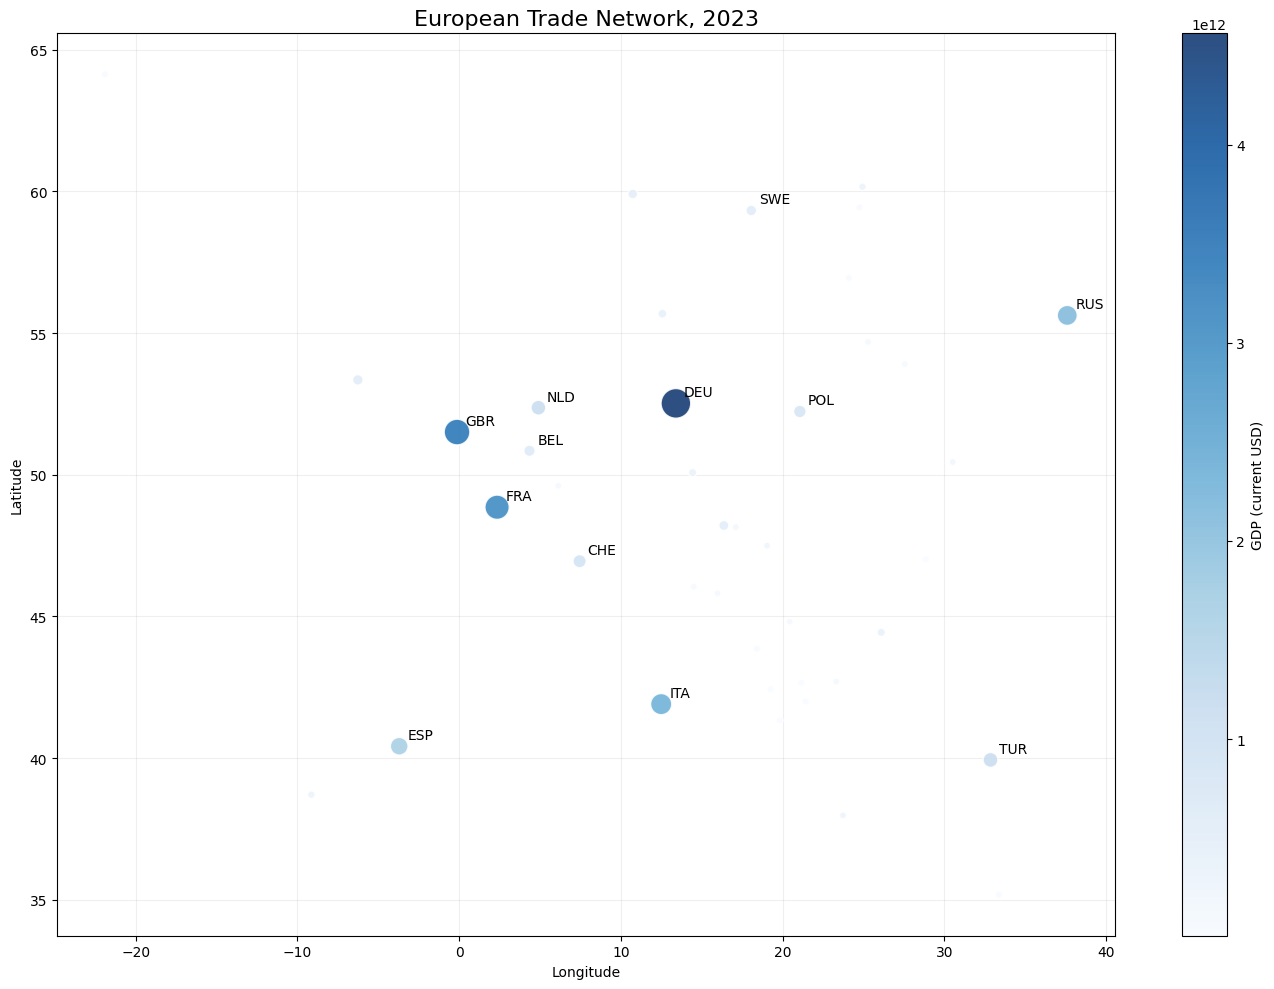

Saved visualization to data/network_2023.png


In [12]:
# Load final saved files to ensure the visualization uses the production outputs.
countries_plot = pd.read_csv('data/countries.csv')
nodes_plot = pd.read_csv('data/nodes.csv')
edges_plot = pd.read_csv('data/edges.csv')

nodes_2023 = nodes_plot[nodes_plot["year"] == YEAR_FOR_VIS].merge(
    countries_plot[["iso3", "countryname", "capital", "lat", "lon"]],
    on="iso3",
    how="left",
)

edges_2023 = edges_plot[edges_plot["year"] == YEAR_FOR_VIS].copy()

fig, ax = plt.subplots(figsize=(14, 10))

sizes = (nodes_2023["gdpusd"] / 1e10).clip(lower=25, upper=700)
scatter = ax.scatter(
    nodes_2023["lon"],
    nodes_2023["lat"],
    s=sizes,
    c=nodes_2023["gdpusd"],
    cmap="Blues",
    alpha=0.85,
    edgecolors="white",
    linewidth=1.0,
    zorder=3,
)

if not edges_2023.empty and {"sourceiso3", "targetiso3", "primaryvalue"}.issubset(edges_2023.columns):
    top_edges = edges_2023.dropna(subset=["sourceiso3", "targetiso3", "primaryvalue"]).nlargest(25, "primaryvalue")
    node_lookup = nodes_2023.set_index("iso3")

    for _, edge in top_edges.iterrows():
        if edge["sourceiso3"] in node_lookup.index and edge["targetiso3"] in node_lookup.index:
            src = node_lookup.loc[edge["sourceiso3"]]
            tgt = node_lookup.loc[edge["targetiso3"]]
            linewidth = min(edge["primaryvalue"] / 1e12 * 4, 3)
            ax.plot(
                [src["lon"], tgt["lon"]],
                [src["lat"], tgt["lat"]],
                color="#666666",
                alpha=0.45,
                linewidth=linewidth,
                zorder=1,
            )

for _, row in nodes_2023.nlargest(12, "gdpusd").iterrows():
    ax.text(row["lon"] + 0.5, row["lat"] + 0.25, row["iso3"], fontsize=10, zorder=4)

ax.set_title("European Trade Network, 2023", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)
plt.colorbar(scatter, ax=ax, label="GDP (current USD)")
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved visualization to {FIG_PATH}")


## 7. Export to SQLite database

The final step converts the three finalized CSV files into one SQLite database. This gives the project a clean handoff format for SQL analysis, graph preparation, and reproducible downstream work.


In [ ]:
if DB_PATH.exists():
    DB_PATH.unlink()

with sqlite3.connect(DB_PATH) as conn:
    pd.read_csv(COUNTRIES_CSV).to_sql("countries", conn, index=False, if_exists="replace")
    pd.read_csv(NODES_CSV).to_sql("nodes", conn, index=False, if_exists="replace")
    pd.read_csv(EDGES_CSV).to_sql("edges", conn, index=False, if_exists="replace")

    summary = pd.read_sql_query(
        """
        SELECT 'countries' AS table_name, COUNT(*) AS row_count FROM countries
        UNION ALL
        SELECT 'nodes' AS table_name, COUNT(*) AS row_count FROM nodes
        UNION ALL
        SELECT 'edges' AS table_name, COUNT(*) AS row_count FROM edges
        """,
        conn,
    )

display(summary)
print(f"Saved database to {DB_PATH}")


,table_name,row_count
0,countries,50
1,nodes,205
2,edges,214


Saved database to data/europe_trade_network.db
